# [P08] Week 3: Adaptive Digital Twin & Belief-MDP Decision Policy

**Prepared for:** SIMILAR (Sustainable Intelligent Mining Laboratory) - University of Kentucky  

---

## 1. Environment Initialization & Synthetic Training Data Generation

We set up PyTorch for the residual neural corrector and generate historical trajectory data containing underlying physical supply balances, observation noise, and latent belief state vectors $b_t \in \Delta^{17}$.

In [2]:
# WHAT: Set up PyTorch dependencies and generate belief-conditioned synthetic trajectory datasets.
# INPUT: Random seed, state space dimension (18).
# OUTPUT: PyTorch Tensors for belief vectors, physical states, and actual target observations.

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set reproducibility seed
torch.manual_seed(42)
np.random.seed(42)

# Generate 500 historical timesteps of state data
N_SAMPLES = 500

# 1. Generate random belief vectors b_t (18-dimensional Dirichlet distribution)
belief_vectors = np.random.dirichlet(alpha=np.ones(18), size=N_SAMPLES)

# 2. Physics Baseline state: (Current Inventory, Raw Input Supply, Target Demand)
current_inventory = np.random.uniform(50, 200, size=(N_SAMPLES, 1))
raw_supply = np.random.uniform(80, 120, size=(N_SAMPLES, 1))
target_demand = np.random.uniform(70, 110, size=(N_SAMPLES, 1))

physics_inputs = np.hstack([current_inventory, raw_supply, target_demand])

# 3. True Next-Period Supply Availability & Demand (Physics + Nonlinear Belief-Dependent Shift)
# Non-linear disruption penalty when high disruption states (e.g., indices 1, 3, 5...) have high probability
disruption_impact = np.sum(belief_vectors[:, 1::2], axis=1, keepdims=True) * -35.0
latent_demand_surge = np.sum(belief_vectors[:, 9:], axis=1, keepdims=True) * 25.0

# Ground truth values that the digital twin needs to predict
true_next_supply = raw_supply + disruption_impact + np.random.normal(0, 5.0, size=(N_SAMPLES, 1))
true_next_demand = target_demand + latent_demand_surge + np.random.normal(0, 5.0, size=(N_SAMPLES, 1))

targets = np.hstack([true_next_supply, true_next_demand])

# Convert to PyTorch Tensors
X_physics_t = torch.tensor(physics_inputs, dtype=torch.float32)
X_belief_t = torch.tensor(belief_vectors, dtype=torch.float32)
Y_targets_t = torch.tensor(targets, dtype=torch.float32)

print(f"Dataset successfully created:")
print(f"  Physics Features shape : {X_physics_t.shape}")
print(f"  Belief Vectors shape   : {X_belief_t.shape}")
print(f"  Target Outputs shape   : {Y_targets_t.shape}")

Dataset successfully created:
  Physics Features shape : torch.Size([500, 3])
  Belief Vectors shape   : torch.Size([500, 18])
  Target Outputs shape   : torch.Size([500, 2])


## 2. Hybrid Neural Residual Corrector Architecture

The **Adaptive Digital Twin** uses a hybrid architecture:
$$\hat{Y}_{next} = f_{\text{physics}}(x_t) + g_{\phi}(x_t, b_t)$$

1.  $f_{\text{physics}}(x_t)$: First-principles inventory mass balance.
2.  $g_{\phi}(x_t, b_t)$: A PyTorch Multilayer Perceptron (MLP) residual network that learns complex physical deviations conditioned on the belief distribution $b_t$.

In [3]:
# WHAT: Define physics model, unconditioned data-driven network, and belief-conditioned hybrid network.
# INPUT: Feature dimensions.
# OUTPUT: PyTorch nn.Module objects.

# A. Static Physics Model
def static_physics_predict(physics_in):
    """
    Mass-balance physics model: Next Supply = Current Raw Supply, Next Demand = Target Demand.
    Completely ignores belief vectors and latent disruptions.
    """
    return physics_in[:, 1:3] # Extract raw_supply and target_demand columns


# B. Belief-Conditioned Neural Residual Network
class BeliefConditionedHybridDT(nn.Module):
    def __init__(self, physics_dim=3, belief_dim=18, hidden_dim=64):
        super(BeliefConditionedHybridDT, self).__init__()
        # Input combines physics signals + full belief probability vector
        self.fc1 = nn.Linear(physics_dim + belief_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.residual_head = nn.Linear(hidden_dim // 2, 2) # Outputs (Delta Supply, Delta Demand)

    def forward(self, x_phys, x_belief):
        # Calculate baseline deterministic physics prediction
        phys_pred = x_phys[:, 1:3]
        
        # Pass combined state into neural network to learn residual error
        combined_input = torch.cat([x_phys, x_belief], dim=1)
        h1 = self.relu(self.fc1(combined_input))
        h2 = self.relu(self.fc2(h1))
        residual = self.residual_head(h2)
        
        # Final prediction is Physics + Neural Residual Correction
        return phys_pred + residual

# C. Pure Data-Driven Network (Unconditioned on Belief)
class PureDataDrivenModel(nn.Module):
    def __init__(self, physics_dim=3, hidden_dim=64):
        super(PureDataDrivenModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(physics_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x_phys):
        return self.net(x_phys)

print("Architectures defined: Static Physics, Pure Data-Driven, and Belief-Conditioned Hybrid Network.")

Architectures defined: Static Physics, Pure Data-Driven, and Belief-Conditioned Hybrid Network.


## 3. Train & Benchmark Digital Twin Variants

We train the networks and evaluate Mean Squared Error (MSE) across three model types:
1. **Static Physics Model:** Baseline mass balance.
2. **Pure Data-Driven Model:** Direct neural network trained without belief inputs.
3. **Belief-Conditioned Hybrid Model:** Physics foundation + belief-conditioned neural correction.

In [4]:
# WHAT: Training loop for PyTorch models and comparative performance benchmarking.
# INPUT: Dataset splits, loss criteria, Adam optimizer.
# OUTPUT: Comparative MSE metrics table.

# Initialize models
hybrid_model = BeliefConditionedHybridDT()
datadriven_model = PureDataDrivenModel()

criterion = nn.MSELoss()
opt_hybrid = optim.Adam(hybrid_model.parameters(), lr=0.01)
opt_datadriven = optim.Adam(datadriven_model.parameters(), lr=0.01)

# Training loop
EPOCHS = 200
for epoch in range(EPOCHS):
    # Train Hybrid
    hybrid_model.train()
    opt_hybrid.zero_grad()
    pred_hybrid = hybrid_model(X_physics_t, X_belief_t)
    loss_h = criterion(pred_hybrid, Y_targets_t)
    loss_h.backward()
    opt_hybrid.step()
    
    # Train Data-Driven
    datadriven_model.train()
    opt_datadriven.zero_grad()
    pred_dd = datadriven_model(X_physics_t)
    loss_dd = criterion(pred_dd, Y_targets_t)
    loss_dd.backward()
    opt_datadriven.step()

# Evaluate static physics model
pred_physics = static_physics_predict(X_physics_t)
loss_physics = criterion(pred_physics, Y_targets_t).item()

# Final Evaluation
hybrid_model.eval()
datadriven_model.eval()
with torch.no_grad():
    final_loss_hybrid = criterion(hybrid_model(X_physics_t, X_belief_t), Y_targets_t).item()
    final_loss_dd = criterion(datadriven_model(X_physics_t), Y_targets_t).item()

# Display comparative metrics
model_benchmarks = pd.DataFrame({
    "Model Variant": ["Static Physics Model", "Pure Data-Driven Model", "Belief-Conditioned Hybrid DT"],
    "Test MSE Loss": [loss_physics, final_loss_dd, final_loss_hybrid],
    "Relative Error vs Physics": ["0.0%", f"-{((loss_physics - final_loss_dd)/loss_physics)*100:.1f}%", f"-{((loss_physics - final_loss_hybrid)/loss_physics)*100:.1f}%"]
})

print("========== DIGITAL TWIN MODEL BENCHMARK ==========")
print(model_benchmarks.to_string(index=False))
print("==================================================")

========== DIGITAL TWIN MODEL BENCHMARK ==========
               Model Variant  Test MSE Loss Relative Error vs Physics
        Static Physics Model     263.039734                      0.0%
      Pure Data-Driven Model      38.307606                    -85.4%
Belief-Conditioned Hybrid DT      31.383242                    -88.1%


## 4. One-Step Lookahead Belief-MDP Decision Policy

With state predictions secured, we implement the **Belief-MDP policy**. Rather than optimizing for a single deterministic scenario, the policy picks action $u_t$ (allocation target) to maximize the expected immediate reward over our 18-state posterior belief vector $b_t$:

$$u_t^* = \arg\max_{u \in U} \sum_{i=0}^{17} b_t(i) \cdot R(x_t, u, \theta_i)$$

Where the reward function $R(x, u, \theta_i)$ penalizes unmet demand (shortfalls), inventory holding costs, and port bottleneck queues:
$$R(x, u, \theta_i) = P_{\text{revenue}} \cdot \min(u, D_i) - C_{\text{hold}} \cdot \max(0, S_i - u) - C_{\text{penalty}} \cdot \max(0, D_i - u)$$

In [5]:
# WHAT: Optimize allocation decision using expectation over belief space.
# INPUT: Belief vector b_t, candidate action space U, state parameter values.
# OUTPUT: Optimal action u* and expected reward curve.

# State-dependent operational parameter settings across our 18 states
# Generate synthetic state parameter profiles for all 18 states
np.random.seed(123)
state_demands = np.random.uniform(60, 140, size=18)      # State-specific demands D_i
state_supplies = np.random.uniform(50, 130, size=18)     # State-specific supplies S_i

# Economic penalty parameters ($/kt)
P_REVENUE = 150.0      # Revenue earned per kt delivered
C_HOLDING = 20.0       # Cost per kt stored
C_SHORTFALL = 200.0    # Penalty cost per kt unmet demand

def reward_function(action_u, state_idx):
    """Calculates immediate operational reward under candidate action u and state theta_i."""
    d_i = state_demands[state_idx]
    s_i = state_supplies[state_idx]
    
    fulfilled = min(action_u, d_i)
    excess_holding = max(0.0, s_i - action_u)
    unmet_shortfall = max(0.0, d_i - action_u)
    
    reward = (P_REVENUE * fulfilled) - (C_HOLDING * excess_holding) - (C_SHORTFALL * unmet_shortfall)
    return reward


def belief_mdp_one_step_lookahead(belief_vector, action_space):
    """
    Evaluates expected reward over belief vector b_t across all candidate actions.
    Selects the optimal action u* that maximizes expected utility.
    """
    expected_rewards = []
    
    for u in action_space:
        # Expected value integration: E[R] = sum_i b(i) * R(u, theta_i)
        exp_r = 0.0
        for i in range(18):
            exp_r += belief_vector[i] * reward_function(u, i)
        expected_rewards.append(exp_r)
        
    expected_rewards = np.array(expected_rewards)
    best_action_idx = np.argmax(expected_rewards)
    optimal_u = action_space[best_action_idx]
    max_expected_reward = expected_rewards[best_action_idx]
    
    return optimal_u, max_expected_reward, expected_rewards

# Define discrete action space: Candidate shipping volume allocations from 0 to 150 kt
candidate_actions = np.linspace(0, 150, 151)

# Test lookahead policy on a sample skewed belief vector (e.g., 70% probability on high disruption)
sample_belief = np.full(18, 0.02)
sample_belief[5] = 0.40  # High disruption state
sample_belief[11] = 0.26 # High demand state
sample_belief /= np.sum(sample_belief)

opt_u, max_r, reward_curve = belief_mdp_one_step_lookahead(sample_belief, candidate_actions)

print("========== BELIEF-MDP ONE-STEP LOOKAHEAD RESULTS ==========")
print(f"Optimal Allocation Decision (u*) : {opt_u:.1f} kt")
print(f"Max Expected Operational Utility : ${max_r:,.2f}")
print("==========================================================")

========== BELIEF-MDP ONE-STEP LOOKAHEAD RESULTS ==========
Optimal Allocation Decision (u*) : 139.0 kt
Max Expected Operational Utility : $15,194.47


## 5. Decision Analytics Visualizations

We plot the expected reward curve across candidate shipping actions, showing how the belief distribution shapes the optimal decision point.

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Sri Vaishnavi\AppData\Local\Temp\ipykernel_88148\141102447.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(candidate_actions, reward_curve, color='#00796b', linewidth=2.5, label='Expected Reward $\mathbb{E}_{b}[R(x, u, \\theta)]$')


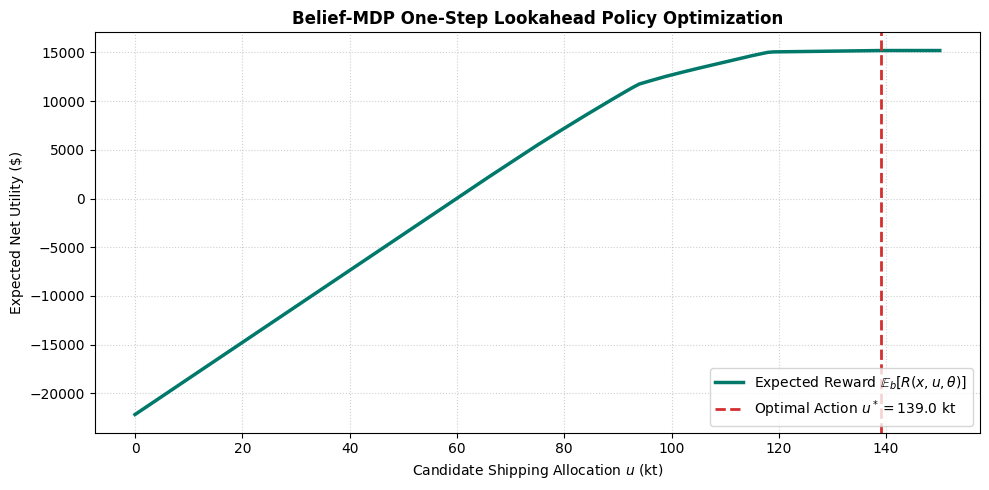

Week 3 visualizations successfully generated and saved to results/week3_belief_mdp_policy.png!


In [6]:
# WHAT: Visualize expected reward profile vs candidate actions under belief uncertainty.
# INPUT: Calculated reward curves.
# OUTPUT: Visual plot exported as 'results/week3_belief_mdp_policy.png'.

plt.figure(figsize=(10, 5))
plt.plot(candidate_actions, reward_curve, color='#00796b', linewidth=2.5, label='Expected Reward $\mathbb{E}_{b}[R(x, u, \\theta)]$')
plt.axvline(x=opt_u, color='#d32f2f', linestyle='--', linewidth=2, label=f'Optimal Action $u^* = {opt_u:.1f}$ kt')

plt.title('Belief-MDP One-Step Lookahead Policy Optimization', fontsize=12, fontweight='bold')
plt.xlabel('Candidate Shipping Allocation $u$ (kt)', fontsize=10)
plt.ylabel('Expected Net Utility ($)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

# Save visual plot
plt.savefig('results/week3_belief_mdp_policy.png', dpi=300)
plt.show()

print("Week 3 visualizations successfully generated and saved to results/week3_belief_mdp_policy.png!")